In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('fill/train_mean_working_re.csv')
test_df = pd.read_csv('fill/test.csv')  # test 데이터 로드
print(df.shape)
# 1. 데이터 분리
X = df.drop(columns=['stress_score'])
y = df['stress_score']



(3000, 26)


# EDA

<Axes: >

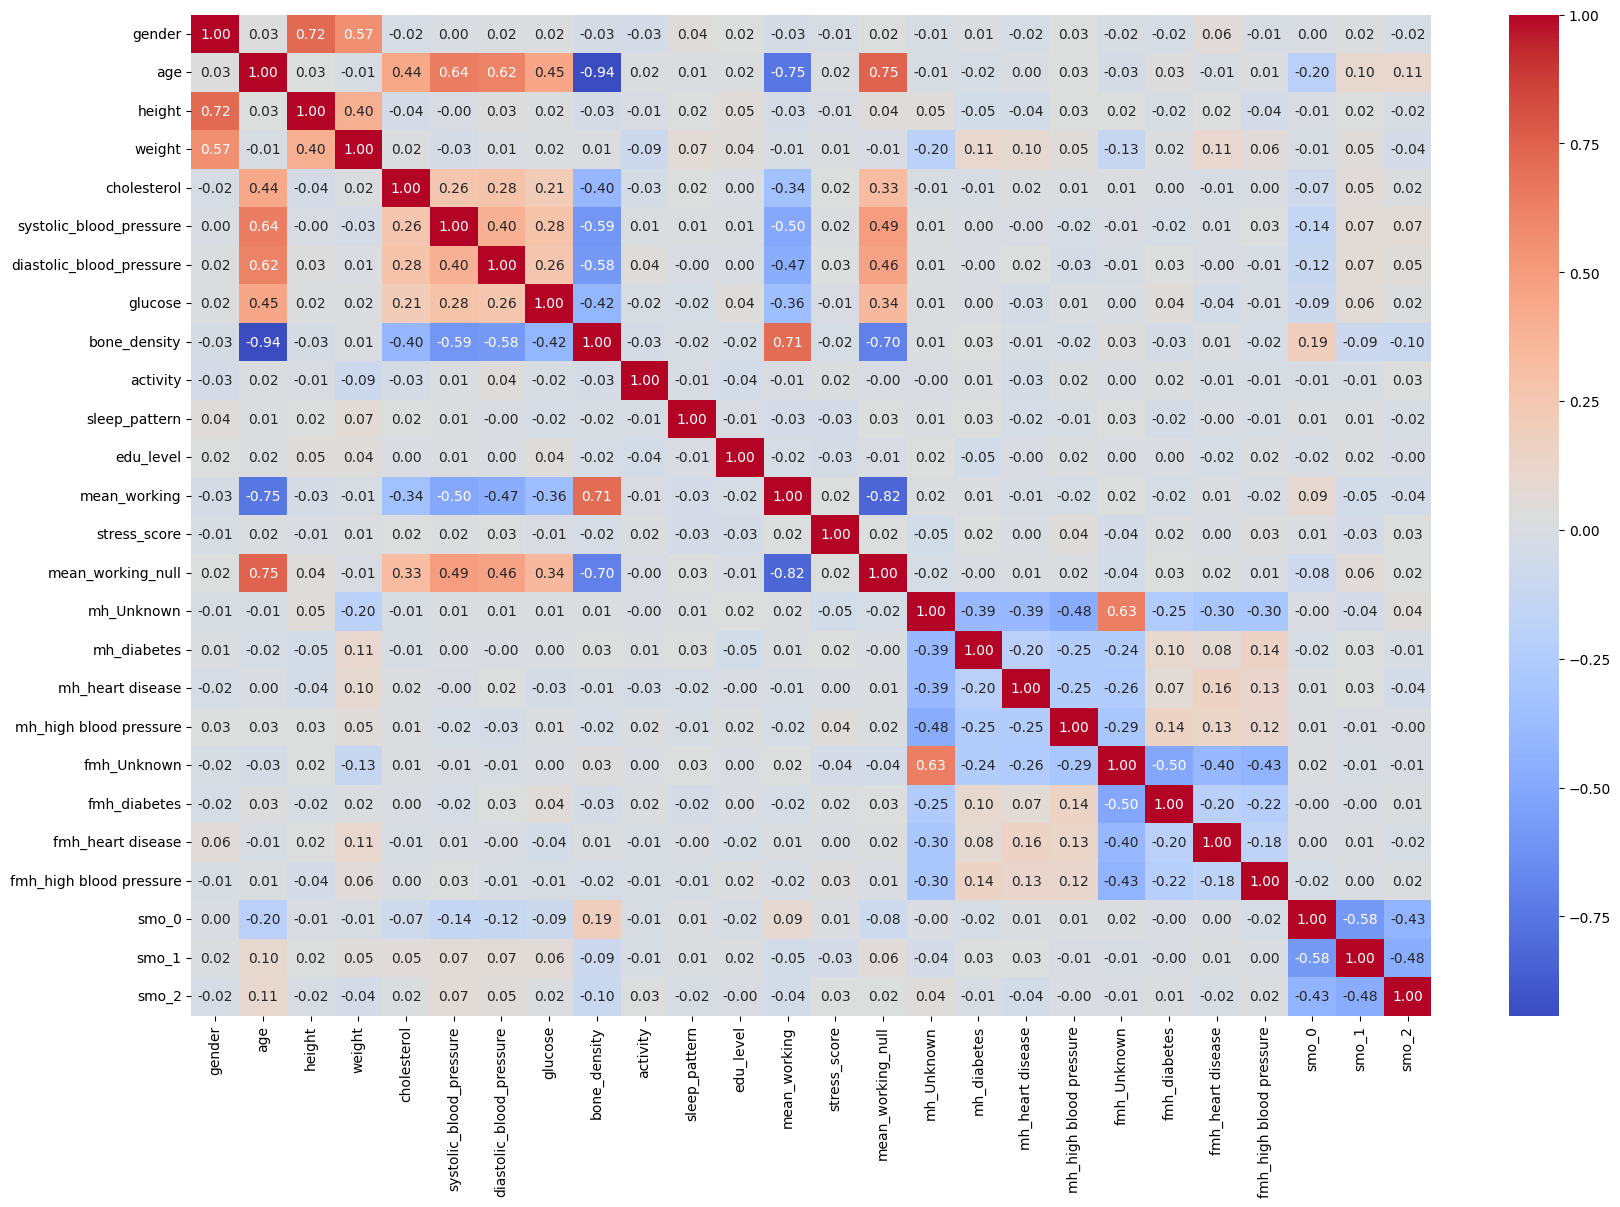

In [7]:
plt.figure(figsize=(20, 13))

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')

<Axes: xlabel='mean_working', ylabel='activity'>

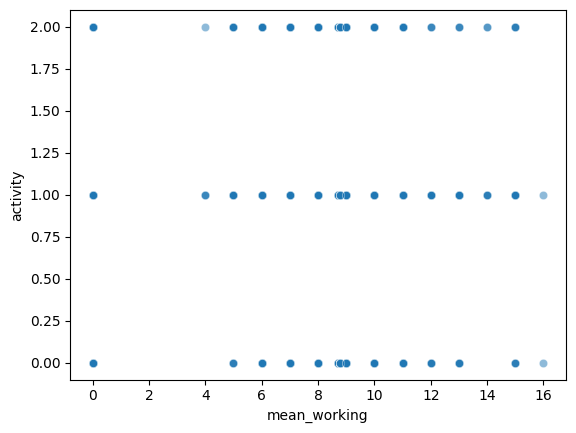

In [5]:
sns.scatterplot(x='mean_working', y='activity', data=df, alpha=0.5)

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler


# 2. (권장) 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 커널 PCA 적용 (예: rbf 커널, 주성분 3개)
kpca = KernelPCA(n_components=3, kernel='rbf', gamma=0.1, random_state=42)
X_kpca = kpca.fit_transform(X_scaled)

# 5. 원본 데이터와 합치기
kpca_cols = [f'kpca_{i+1}' for i in range(X_kpca.shape[1])]
df_kpca = pd.DataFrame(X_kpca, columns=kpca_cols, index=df.index)
df_augmented = pd.concat([X, df_kpca], axis=1).values

In [194]:

# 5. 원본 데이터와 합치기
kpca_cols = [f'kpca_{i+1}' for i in range(X_kpca.shape[1])]
df_kpca = pd.DataFrame(X_kpca, columns=kpca_cols, index=df.index)
df_augmented = pd.concat([X, df_kpca], axis=1).values


In [195]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import xgboost as xgb


def tune_xgb_mae_cv(X, y, max_evals=60, n_splits=5, random_state=42,early_stopping_rounds=30):
    X_arr = X.values if hasattr(X, "values") else X
    y_arr = y.values if hasattr(y, "values") else y

    def objective(params):
        # 정수 변환
        params["max_depth"] = int(params["max_depth"])
        params["n_estimators"] = int(params["n_estimators"])
        params["min_child_weight"] = int(params["min_child_weight"])

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        fold_maes = []

        for tr_idx, val_idx in kf.split(X_arr):
            X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
            y_tr, y_val = y_arr[tr_idx], y_arr[val_idx]

            model = xgb.XGBRegressor(
                eval_metric="mae",
                verbosity=0,
                early_stopping_rounds= early_stopping_rounds,
                **params,

            )

            model.fit(
                X_tr, 
                y_tr,
                eval_set=[(X_val, y_val)],
                verbose=False,
            )

            pred = model.predict(X_val)
            fold_maes.append(mean_absolute_error(y_val, pred))

        mean_mae = np.mean(fold_maes)
        return {"loss": mean_mae, "status": STATUS_OK}

    # regularization candiate 정의
    reg_candidate = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1, 5, 10,20,30]

    # space 정의, Hyperparameter의 이름을 key 값으로 입력
    space={
        'max_depth': hp.quniform("max_depth", 3, 14, 1),
        'learning_rate': hp.quniform ('learning_rate', 0.01, 0.5, 0.01),
        'reg_alpha' : hp.choice('reg_alpha', reg_candidate),
        'reg_lambda' : hp.choice('reg_lambda', reg_candidate), # 인덱스 값이 나옴
        'subsample': hp.quniform('subsample', 0.6, 1, 0.1),
        'colsample_bytree' : hp.quniform('colsample_bytree', 0.5, 1, 0.1),
        'min_child_weight' : hp.quniform('min_child_weight', 1, 5, 1),
        'n_estimators': hp.quniform('n_estimators', 500, 1300, 100)
        }

    trials = Trials()
    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(random_state),
    )

    best_params = {
        "max_depth": int(best["max_depth"]),
        "learning_rate": best["learning_rate"],
        "n_estimators": int(best["n_estimators"]),
        "subsample": best["subsample"],
        "colsample_bytree": best["colsample_bytree"],
        "min_child_weight": int(best["min_child_weight"]),
        "reg_alpha": best["reg_alpha"],
        "reg_lambda": best["reg_lambda"]
    }

    best_mae = min([r["loss"] for r in trials.results])

    return {
        "best_params": best_params, 
        "best_cv_mae": best_mae,
        "trials": trials,
    }




In [196]:
df_augmented.shape

(3000, 27)

In [197]:
# X, y는 numpy array여야 함 (예: pandas라면 .values로)
summary = tune_xgb_mae_cv(df_augmented,
                         y,
                          max_evals=80,
                          n_splits=5)
print("CV MAE:", summary["best_cv_mae"])
print("Best params:", summary["best_params"])


  0%|          | 0/80 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 80/80 [10:57<00:00,  8.22s/trial, best loss: 0.16954800599722814]
CV MAE: 0.16954800599722814
Best params: {'max_depth': 13, 'learning_rate': 0.11, 'n_estimators': 1300, 'subsample': 0.9, 'colsample_bytree': 0.5, 'min_child_weight': 3, 'reg_alpha': 3, 'reg_lambda': 8}


train mae 0.04978367864719282


<Axes: >

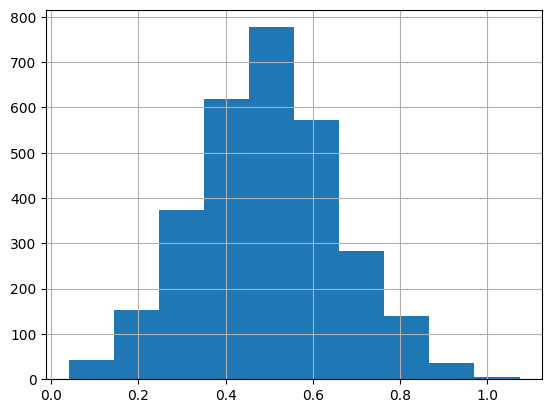

In [ ]:
xgb_reg_candidate = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1, 5, 10,20,30]
xgb_params =   {'max_depth': 13, 'learning_rate': 0.11, 'n_estimators': 1300, 'subsample': 0.9, 'colsample_bytree': 0.5, 'min_child_weight': 3, 'reg_alpha': xgb_reg_candidate[3], 'reg_lambda': xgb_reg_candidate[8]}

model = xgb.XGBRegressor(random_state=42,
                         **xgb_params
                         )
model.fit(df_augmented, y)
train_pred = model.predict(df_augmented)
mae = mean_absolute_error(y, train_pred)

print(f'train mae {mae}')
test_scaled = scaler.transform(test_df)
test_kpca = kpca.transform(test_scaled)
test_kpca_df = pd.DataFrame(test_kpca, columns=kpca_cols, index=test_df.index)
test_df_augmented = pd.concat([test_df, test_kpca_df], axis=1).values


pred = model.predict(test_df_augmented)
submit = pd.read_csv('open/sample_submission.csv')
submit['stress_score'] = pred
submit.to_csv('submission_base.csv', index=False)
submit['stress_score'].hist()

In [183]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=12, random_state=42)
gmm.fit(X)
probs = gmm.predict_proba(X)  # 각 군집에 속할 확률
clusters = gmm.predict(X)     # 최대확률 군집 번호

# 피처로 활용
import pandas as pd
df_gmm = pd.DataFrame(probs, columns=[f'gmm_prob_{i}' for i in range(1,13)])
df_with_gmm = pd.concat([X, df_gmm], axis=1).values

# 가우시안믹스처모델
from sklearn.model_selection import KFold
import xgboost as xgb 
from sklearn.metrics import mean_absolute_error

li = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)
#df_with_gmm = np.concatenate([X.values,clusters.reshape(-1,1)],axis = 1)

for train_index, val_index in kf.split(df_with_gmm):
    x_train, x_val = df_with_gmm[train_index], df_with_gmm[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # 선형 회귀 모델 학습
    model = xgb.XGBRegressor() 
    model.fit(x_train, y_train) 

    # 검증 데이터에 대한 예측
    y_pred = model.predict(x_val) 

    # MAE 계산
    mae = mean_absolute_error(y_val, y_pred)
    li.append(mae)
     
print(f'Fold MAE: {np.mean(li):.4f}')

Fold MAE: 0.1960


C:\Users\yunji\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yunji\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yunji\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yunji\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


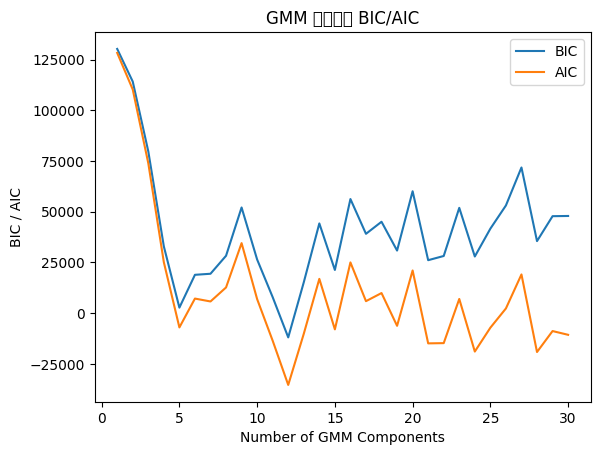

최적 GMM 군집 개수 (BIC 기준): 12


In [155]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

bic_list = []
aic_list = []
n_range = range(1,31)  # 1~12개 군집 시도 (필요시 범위 조정)

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X)
    bic_list.append(gmm.bic(X))
    aic_list.append(gmm.aic(X))
 
plt.plot(n_range, bic_list, label='BIC')
plt.plot(n_range, aic_list, label='AIC')
plt.xlabel('Number of GMM Components')
plt.ylabel('BIC / AIC')
plt.legend()
plt.title('GMM 군집수별 BIC/AIC')
plt.show()

# 최적 n은 BIC/AIC가 가장 작은 지점 
best_n = n_range[np.argmin(bic_list)]
print('최적 GMM 군집 개수 (BIC 기준):', best_n)

In [ ]:

# 기본모델 교차검증 테스트
from sklearn.model_selection import KFold
import xgboost as xgb 
from sklearn.metrics import mean_absolute_error

li = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)


for train_index, val_index in kf.split(df_augmented):
    x_train, x_val = df_augmented[train_index], df_augmented[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # 선형 회귀 모델 학습
    model = xgb.XGBRegressor() 
    model.fit(x_train, y_train) 

    # 검증 데이터에 대한 예측
    y_pred = model.predict(x_val) 

    # MAE 계산
    mae = mean_absolute_error(y_val, y_pred)
    li.append(mae)
    
print(f'Fold MAE: {np.mean(li):.4f}')